# 2022/1/20 U L_clouds Pattern

# Module 引入

In [1]:
import os
import numpy as np
import scipy as sp
import pandas as pd
from datetime import date
import marineHeatWaves as mhw
import netCDF4 as nc
import datetime
import matplotlib.pyplot as plt
from tqdm import notebook
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
import matplotlib.ticker as mticker
import PIL.Image as Image
import io
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor

# 常量生成与导入

In [2]:
lat_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lats.npy')[-1::-1]
lon_4=np.load('/lustre/home/yuhanxue/data/ERA/0.25area/re/lons.npy')
area1_lat=(lat_4>=35)&(lat_4<=50)
area1_lon=(lon_4>=195)&(lon_4<=230)
Lon,Lat=np.meshgrid(lon_4[area1_lon],lat_4[area1_lat])
U10=np.load(rf'/lustre/home/yuhanxue/data/ERA/0.25area/re/new/u10s.npy')# 10 metre U wind component (m s**-1)
V10=np.load(rf'/lustre/home/yuhanxue/data/ERA/0.25area/re/new/v10s.npy')# 10 metre V wind component (m s**-1)
Lcc=np.load(rf'/lustre/home/yuhanxue/data/ERA/0.25area/re/new/lccs.npy')# Low cloud cover ((0 - 1))
SRad=np.load('/lustre/home/yuhanxue/data/ERA/ERA_4newQ/re/new_msnswrfs.npy')#ShortwaveRadiation
time_need=pd.date_range('2021-7-1','2021-9-30')
time=pd.date_range('1993-1-1','2021-12-31',freq='1D')

# Clim

In [3]:
def runavg(ts, w):
    '''
    Performs a running average of an input time series using uniform window
    of width w. This function assumes that the input time series is periodic.
    Inputs:
      ts            Time series [1D numpy array]
      w             Integer length (must be odd) of running average window
    Outputs:
      ts_smooth     Smoothed time series
    Written by Eric Oliver, Institue for Marine and Antarctic Studies, University of Tasmania, Feb-Mar 2015
    '''
    # Original length of ts
    N = len(ts)
    # make ts three-fold periodic
    ts = np.append(ts, np.append(ts, ts))
    # smooth by convolution with a window of equal weights
    ts_smooth = np.convolve(ts, np.ones(w)/w, mode='same')
    # Only output central section, of length equal to the original length of ts
    ts = ts_smooth[N:2*N]
    return ts

def Clim(t, data, climatologyPeriod=[None,None],  windowHalfWidth=5, smoothPercentile=True, smoothPercentileWidth=31,alternateClimatology=False, Ly=False):
    T = len(t)
    year = np.zeros((T))
    month = np.zeros((T))
    day = np.zeros((T))
    doy = np.zeros((T))
    for i in range(T):
        year[i] = date.fromordinal(t[i]).year
        month[i] = date.fromordinal(t[i]).month
        day[i] = date.fromordinal(t[i]).day
    # Leap-year baseline for defining day-of-year values
    year_leapYear = 2012 # This year was a leap-year and therefore doy in range of 1 to 366
    t_leapYear = np.arange(date(year_leapYear, 1, 1).toordinal(),date(year_leapYear, 12, 31).toordinal()+1)
    dates_leapYear = [date.fromordinal(tt.astype(int)) for tt in t_leapYear]
    month_leapYear = np.zeros((len(t_leapYear)))
    day_leapYear = np.zeros((len(t_leapYear)))
    doy_leapYear = np.zeros((len(t_leapYear)))
    for tt in range(len(t_leapYear)):
        month_leapYear[tt] = date.fromordinal(t_leapYear[tt]).month
        day_leapYear[tt] = date.fromordinal(t_leapYear[tt]).day
        doy_leapYear[tt] = t_leapYear[tt] - date(date.fromordinal(t_leapYear[tt]).year,1,1).toordinal() + 1
    # Calculate day-of-year values
    for tt in range(T):
        doy[tt] = doy_leapYear[(month_leapYear == month[tt]) * (day_leapYear == day[tt])]

    # Constants (doy values for Feb-28 and Feb-29) for handling leap-years
    feb28 = 59
    feb29 = 60

    # Set climatology period, if unset use full range of available data
    if (climatologyPeriod[0] is None) or (climatologyPeriod[1] is None):
        climatologyPeriod[0] = year[0]
        climatologyPeriod[1] = year[-1]

    #
    # Calculate threshold and seasonal climatology (varying with day-of-year)
    #

    # if alternate temperature time series is supplied for the calculation of the climatology
    if alternateClimatology:
        tClim = alternateClimatology[0]
        tempClim = alternateClimatology[1]
        TClim = len(tClim)
        yearClim = np.zeros((TClim))
        monthClim = np.zeros((TClim))
        dayClim = np.zeros((TClim))
        doyClim = np.zeros((TClim))
        for i in range(TClim):
            yearClim[i] = date.fromordinal(tClim[i]).year
            monthClim[i] = date.fromordinal(tClim[i]).month
            dayClim[i] = date.fromordinal(tClim[i]).day
            doyClim[i] = doy_leapYear[(month_leapYear == monthClim[i]) * (day_leapYear == dayClim[i])]
    else:
        tempClim = data.copy()
        TClim = np.array([T]).copy()[0]
        yearClim = year.copy()
        monthClim = month.copy()
        dayClim = day.copy()
        doyClim = doy.copy() 
    lenClimYear = 366
    # Start and end indices
    clim_start = np.where(yearClim == climatologyPeriod[0])[0][0]
    clim_end = np.where(yearClim == climatologyPeriod[1])[0][-1]
    # Inialize arrays
    seas_climYear = np.NaN*np.zeros(lenClimYear)
    clim = {}
    clim['seas'] = np.NaN*np.zeros(TClim)
    # Loop over all day-of-year values, and calculate threshold and seasonal climatology across years
    for d in range(1,lenClimYear+1):
        # Special case for Feb 29
        if d == feb29:
            continue
        # find all indices for each day of the year +/- windowHalfWidth and from them calculate the threshold
        tt0 = np.where(doyClim[clim_start:clim_end+1] == d)[0] 
        # If this doy value does not exist (i.e. in 360-day calendars) then skip it
        if len(tt0) == 0:
            continue
        tt = np.array([])
        for w in range(-windowHalfWidth, windowHalfWidth+1):
            tt = np.append(tt, clim_start+tt0 + w)
        tt = tt[tt>=0] # Reject indices "before" the first element
        tt = tt[tt<TClim] # Reject indices "after" the last element
        seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
    # Special case for Feb 29
    seas_climYear[feb29-1] = 0.5*seas_climYear[feb29-2] + 0.5*seas_climYear[feb29]

    #return seas_climYear
    # Smooth if desired
    if smoothPercentile:
        # If the length of year is < 365/366 (e.g. a 360 day year from a Climate Model)
        if Ly:

            valid = ~np.isnan(seas_climYear)
            seas_climYear[valid] = runavg(seas_climYear[valid], smoothPercentileWidth)
        # >= 365-day year
        else:

            seas_climYear = runavg(seas_climYear, smoothPercentileWidth)

    #print(doy)
    #clim['seas'] = seas_climYear[doy.astype(int)-1]

    # Save vector indicating which points in temp are missing values
    #clim['missing'] = np.isnan(data)
    # Set all remaining missing temp values equal to the climatology
    #data[np.isnan(data)] = clim['seas'][np.isnan(data)]

    return seas_climYear[doy.astype(int)-1]


In [4]:
def clim_spacemean(dat):
    t=np.arange(date(1993,1,1).toordinal(),date(2021,12,31).toordinal()+1)
    return Clim(t,np.mean(np.mean(dat,axis=-1),axis=-1))
U10_time_Clim=clim_spacemean(U10)
V10_time_Clim=clim_spacemean(V10)
Lcc_time_Clim=clim_spacemean(Lcc)
SRad_time_Clim=clim_spacemean(SRad)
WindSpeed=clim_spacemean((U10**2+V10**2)**0.5)

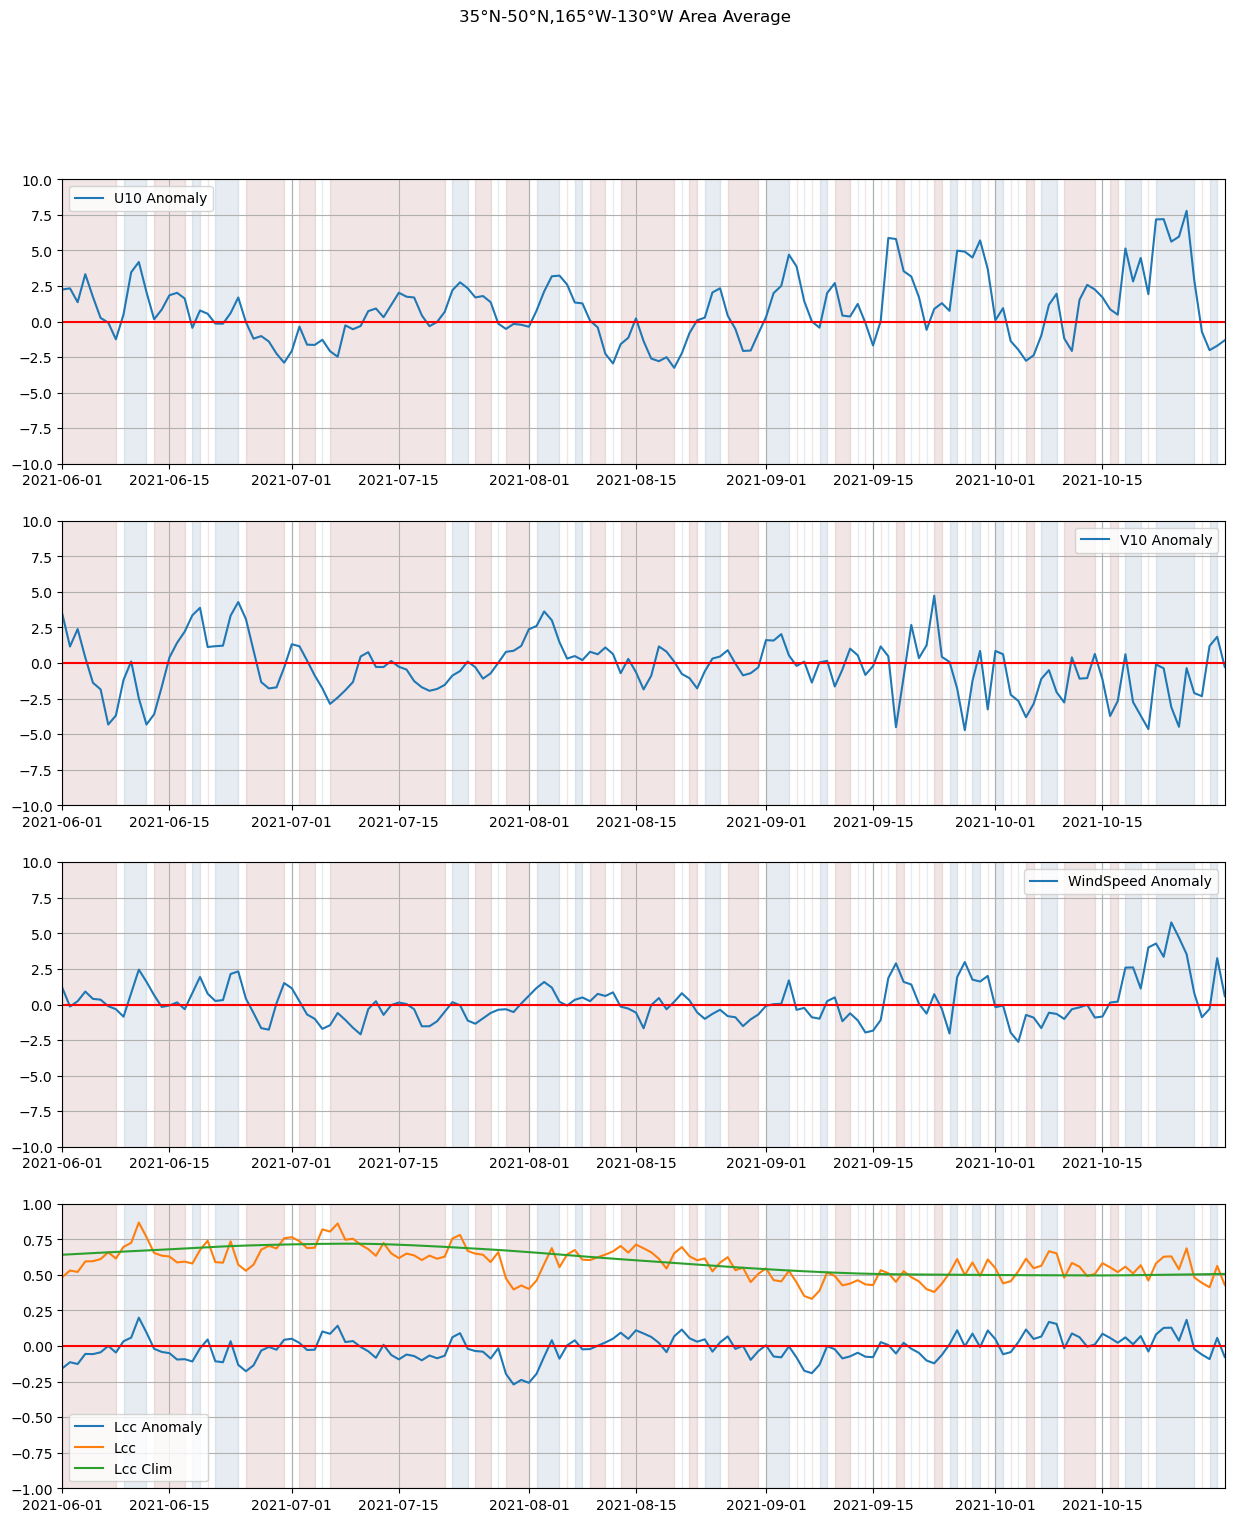

In [9]:
plt.figure(figsize=[15,17])
plt.suptitle('35°N-50°N,165°W-130°W Area Average')
y0=np.zeros(shape=[time.shape[0]])
y1=np.copy(y0)
y1[:]=1000
y0[:]=-1000
plt.subplot(4,1,1)
plt.plot(time,np.nanmean(np.nanmean(U10,axis=1),axis=1)-U10_time_Clim,label='U10 Anomaly')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=6)&(time.month<=10)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-10,10)
plt.fill_between(time,y0,y1,where=np.nanmean(np.nanmean(SRad,axis=1),axis=1)-SRad_time_Clim>0,alpha=0.1,color='#840000')
plt.fill_between(time,y0,y1,where=np.nanmean(np.nanmean(SRad,axis=1),axis=1)-SRad_time_Clim<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()

plt.subplot(4,1,2)
plt.plot(time,np.nanmean(np.nanmean(V10,axis=1),axis=1)-V10_time_Clim,label='V10 Anomaly')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=6)&(time.month<=10)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-10,10)
plt.fill_between(time,y0,y1,where=np.nanmean(np.nanmean(SRad,axis=1),axis=1)-SRad_time_Clim>0,alpha=0.1,color='#840000')
plt.fill_between(time,y0,y1,where=np.nanmean(np.nanmean(SRad,axis=1),axis=1)-SRad_time_Clim<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()


plt.subplot(4,1,3)
plt.plot(time,np.nanmean(np.nanmean((U10**2+V10**2)**0.5,axis=1),axis=1)-WindSpeed,label='WindSpeed Anomaly')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=6)&(time.month<=10)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-10,10)
plt.fill_between(time,y0,y1,where=np.nanmean(np.nanmean(SRad,axis=1),axis=1)-SRad_time_Clim>0,alpha=0.1,color='#840000')
plt.fill_between(time,y0,y1,where=np.nanmean(np.nanmean(SRad,axis=1),axis=1)-SRad_time_Clim<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()

plt.subplot(4,1,4)
plt.plot(time,np.nanmean(np.nanmean(Lcc,axis=1),axis=1)-Lcc_time_Clim,label='Lcc Anomaly')
plt.plot(time,np.nanmean(np.nanmean(Lcc,axis=1),axis=1),label='Lcc')
plt.plot(time,Lcc_time_Clim,label='Lcc Clim')
plt.plot(time,np.array([0]*time.shape[0]),'r')
time_ind=(time.year==2021)&(time.month>=6)&(time.month<=10)
plt.xlim(time[time_ind][0],time[time_ind][-1])
plt.ylim(-1,1)
plt.fill_between(time,y0,y1,where=np.nanmean(np.nanmean(SRad,axis=1),axis=1)-SRad_time_Clim>0,alpha=0.1,color='#840000')
plt.fill_between(time,y0,y1,where=np.nanmean(np.nanmean(SRad,axis=1),axis=1)-SRad_time_Clim<0,alpha=0.1,color='#10457e')
plt.legend()
plt.grid()

# WindSpeed Anomaly

In [135]:
def clim_cal(dat):
    t=np.arange(date(1993,1,1).toordinal(),date(2021,12,31).toordinal()+1)
    return np.array(Clim(t,dat))
def clim_map(dat):
    pool = ProcessPoolExecutor(max_workers=9)
    ans=np.array(list(pool.map(clim_cal,dat)))
    del pool
    return ans
def clim_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    pool = ProcessPoolExecutor(max_workers=8)
    ans=np.array(list(pool.map(clim_map,a)))
    del pool
    a=np.swapaxes(ans,2,1)
    a=np.swapaxes(a,1,0)
    return a
U10_clim=clim_allinone(U10)
V10_clim=clim_allinone(V10)
WindSpeed_clim=clim_allinone((U10**2+V10**2)**0.5)
U10_ano=U10-U10_clim
V10_ano=V10-V10_clim
WindSpeed_ano=(U10**2+V10**2)**0.5-WindSpeed_clim

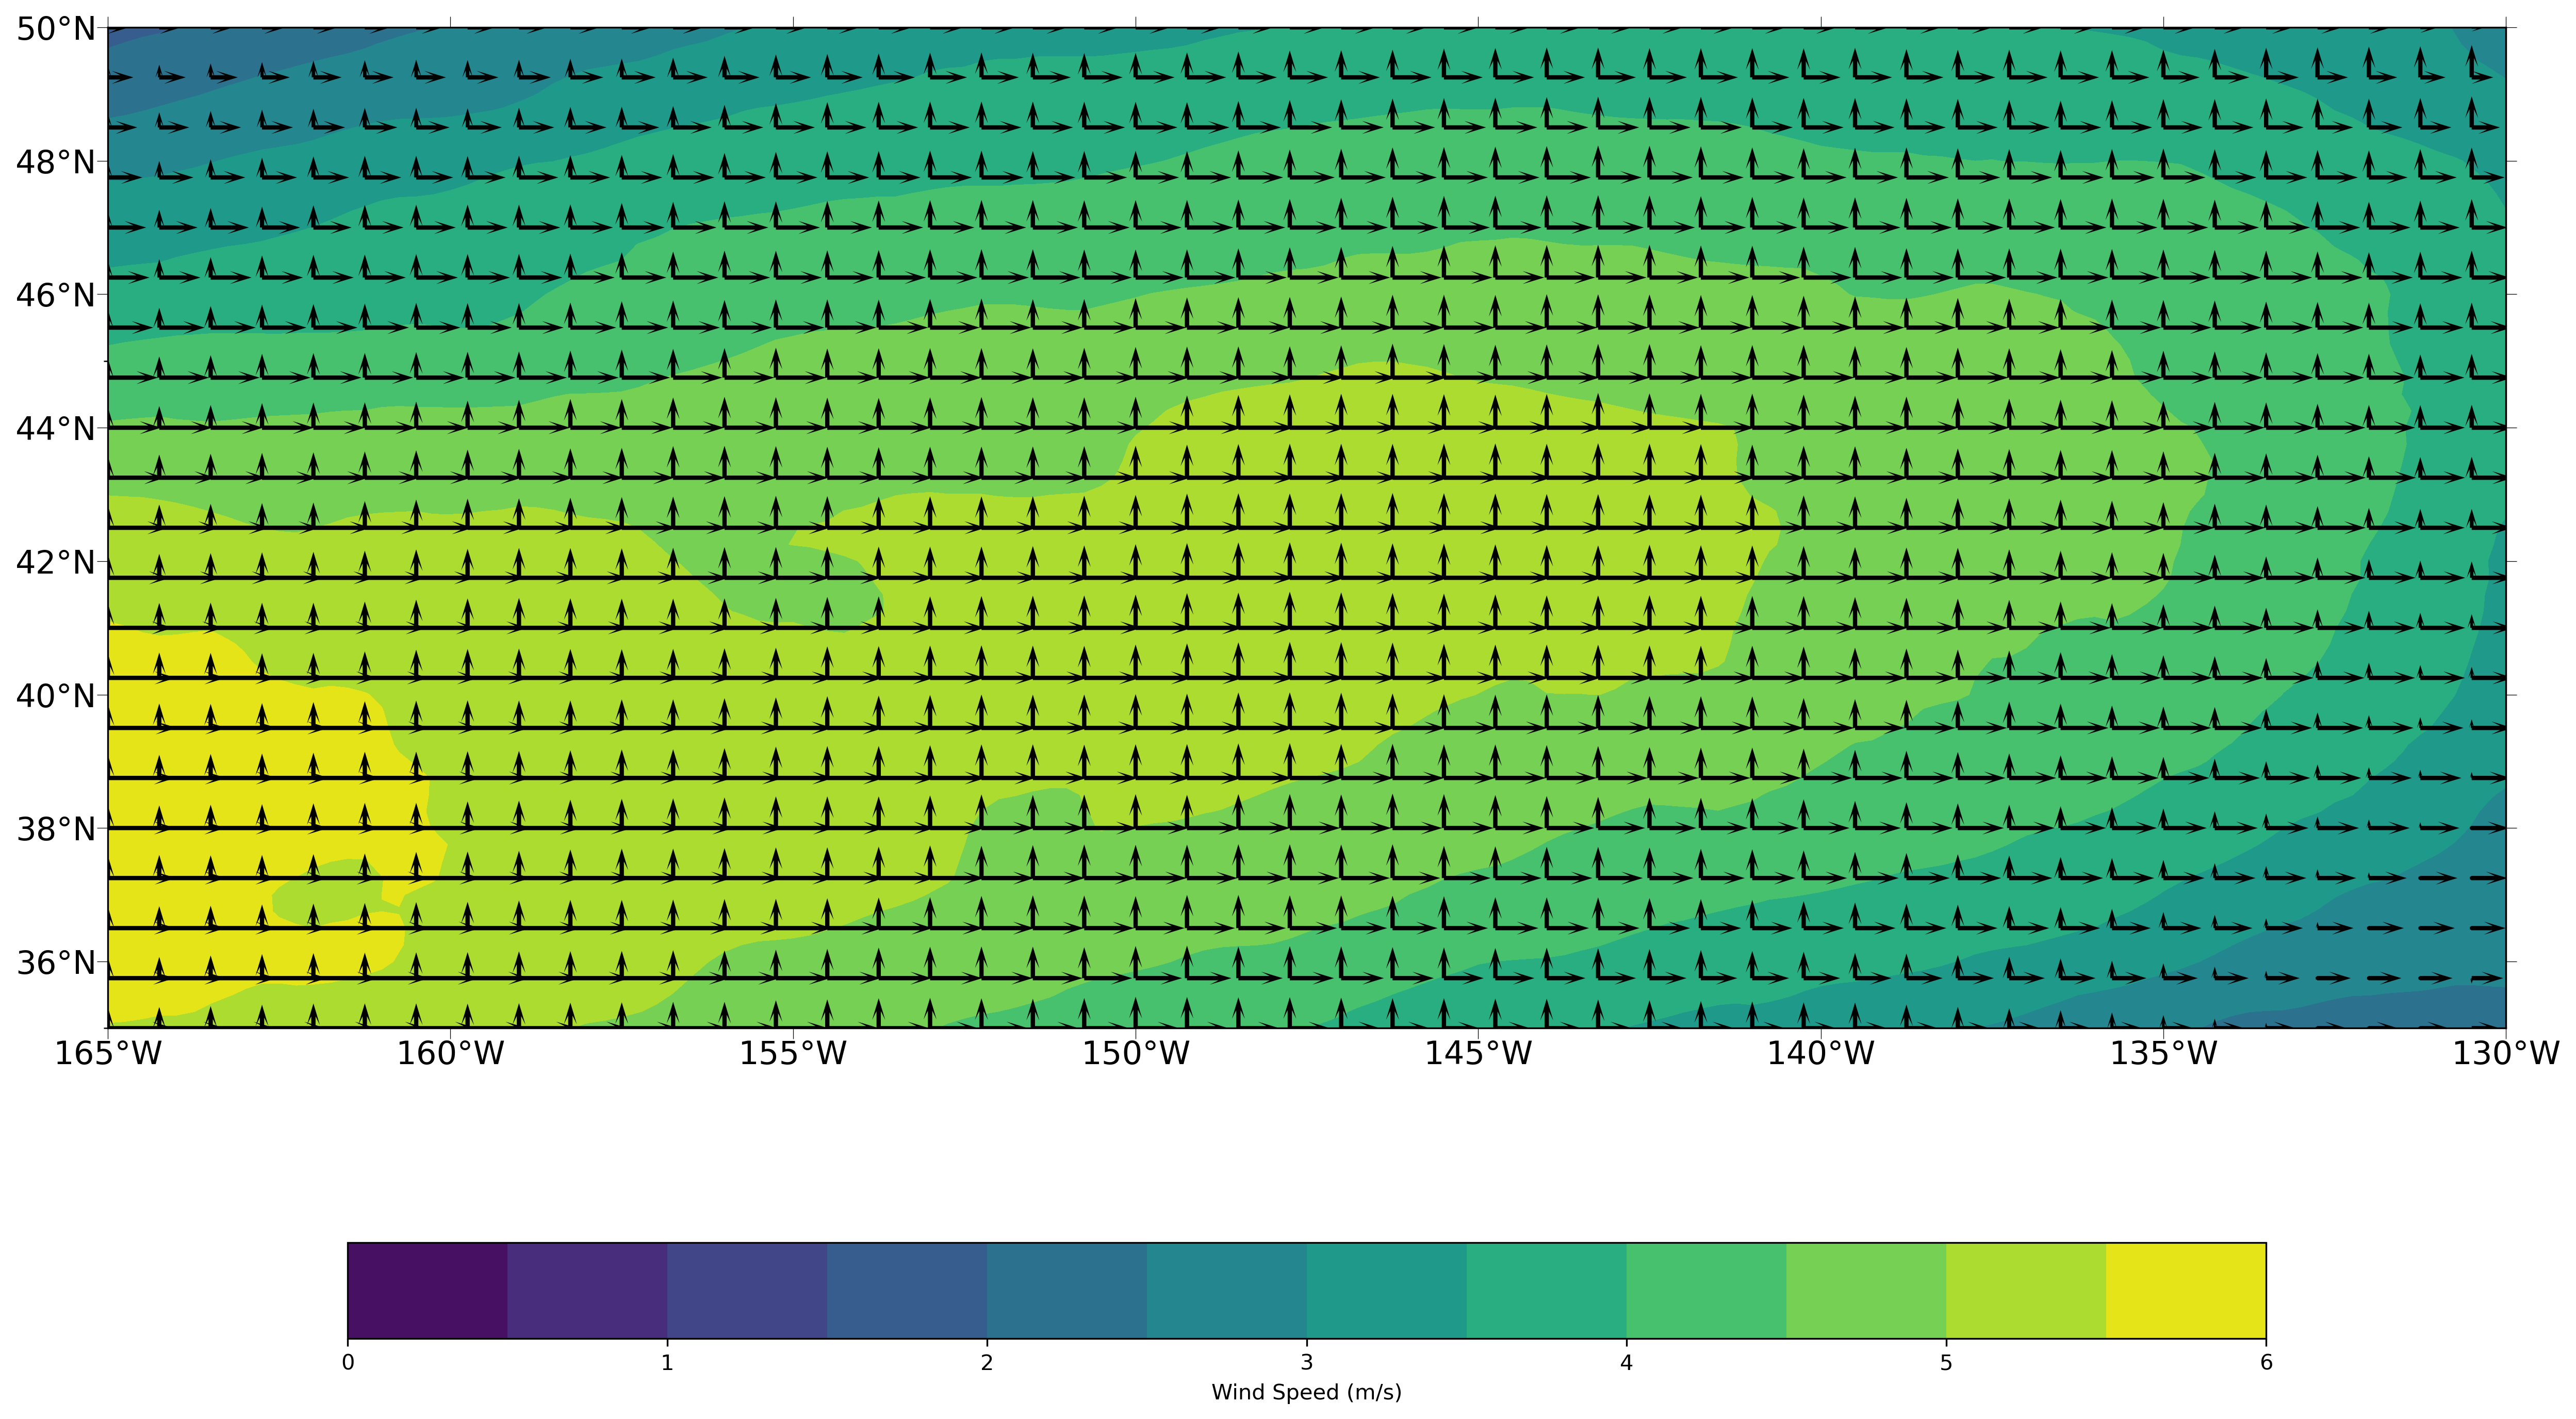

In [152]:
fig, ax = plt.subplots(figsize=(20,12),dpi=300)
c=ax.contourf(Lon,Lat,(demoU**2+demoV**2)**0.5,np.arange(0,6.1,0.5))
vec=ax.quiver(Lon[::3,::3],Lat[::3,::3],demoU[::3,::3],np.zeros(shape=demoV.shape)[::3,::3],pivot='tail',width=0.0018,headwidth=3,headaxislength=3,scale=190)
vec=ax.quiver(Lon[::3,::3],Lat[::3,::3],np.zeros(shape=demoU.shape)[::3,::3],demoV[::3,::3],pivot='tail',width=0.0018,headwidth=3,headaxislength=3,scale=190)
ax.xaxis.set_major_formatter(LongitudeFormatter())#刻度格式转换为经纬度样式 
ax.yaxis.set_major_formatter(LatitudeFormatter())
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))#刻度格式转换为经纬度样式 
ax.yaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.tick_params(axis='both',which='major',labelsize=15,direction='out',length=5,width=0.3,pad=0.2,top=True,right=True)
plt.colorbar(c,orientation='horizontal',label='Wind Speed (m/s)',shrink=0.8)


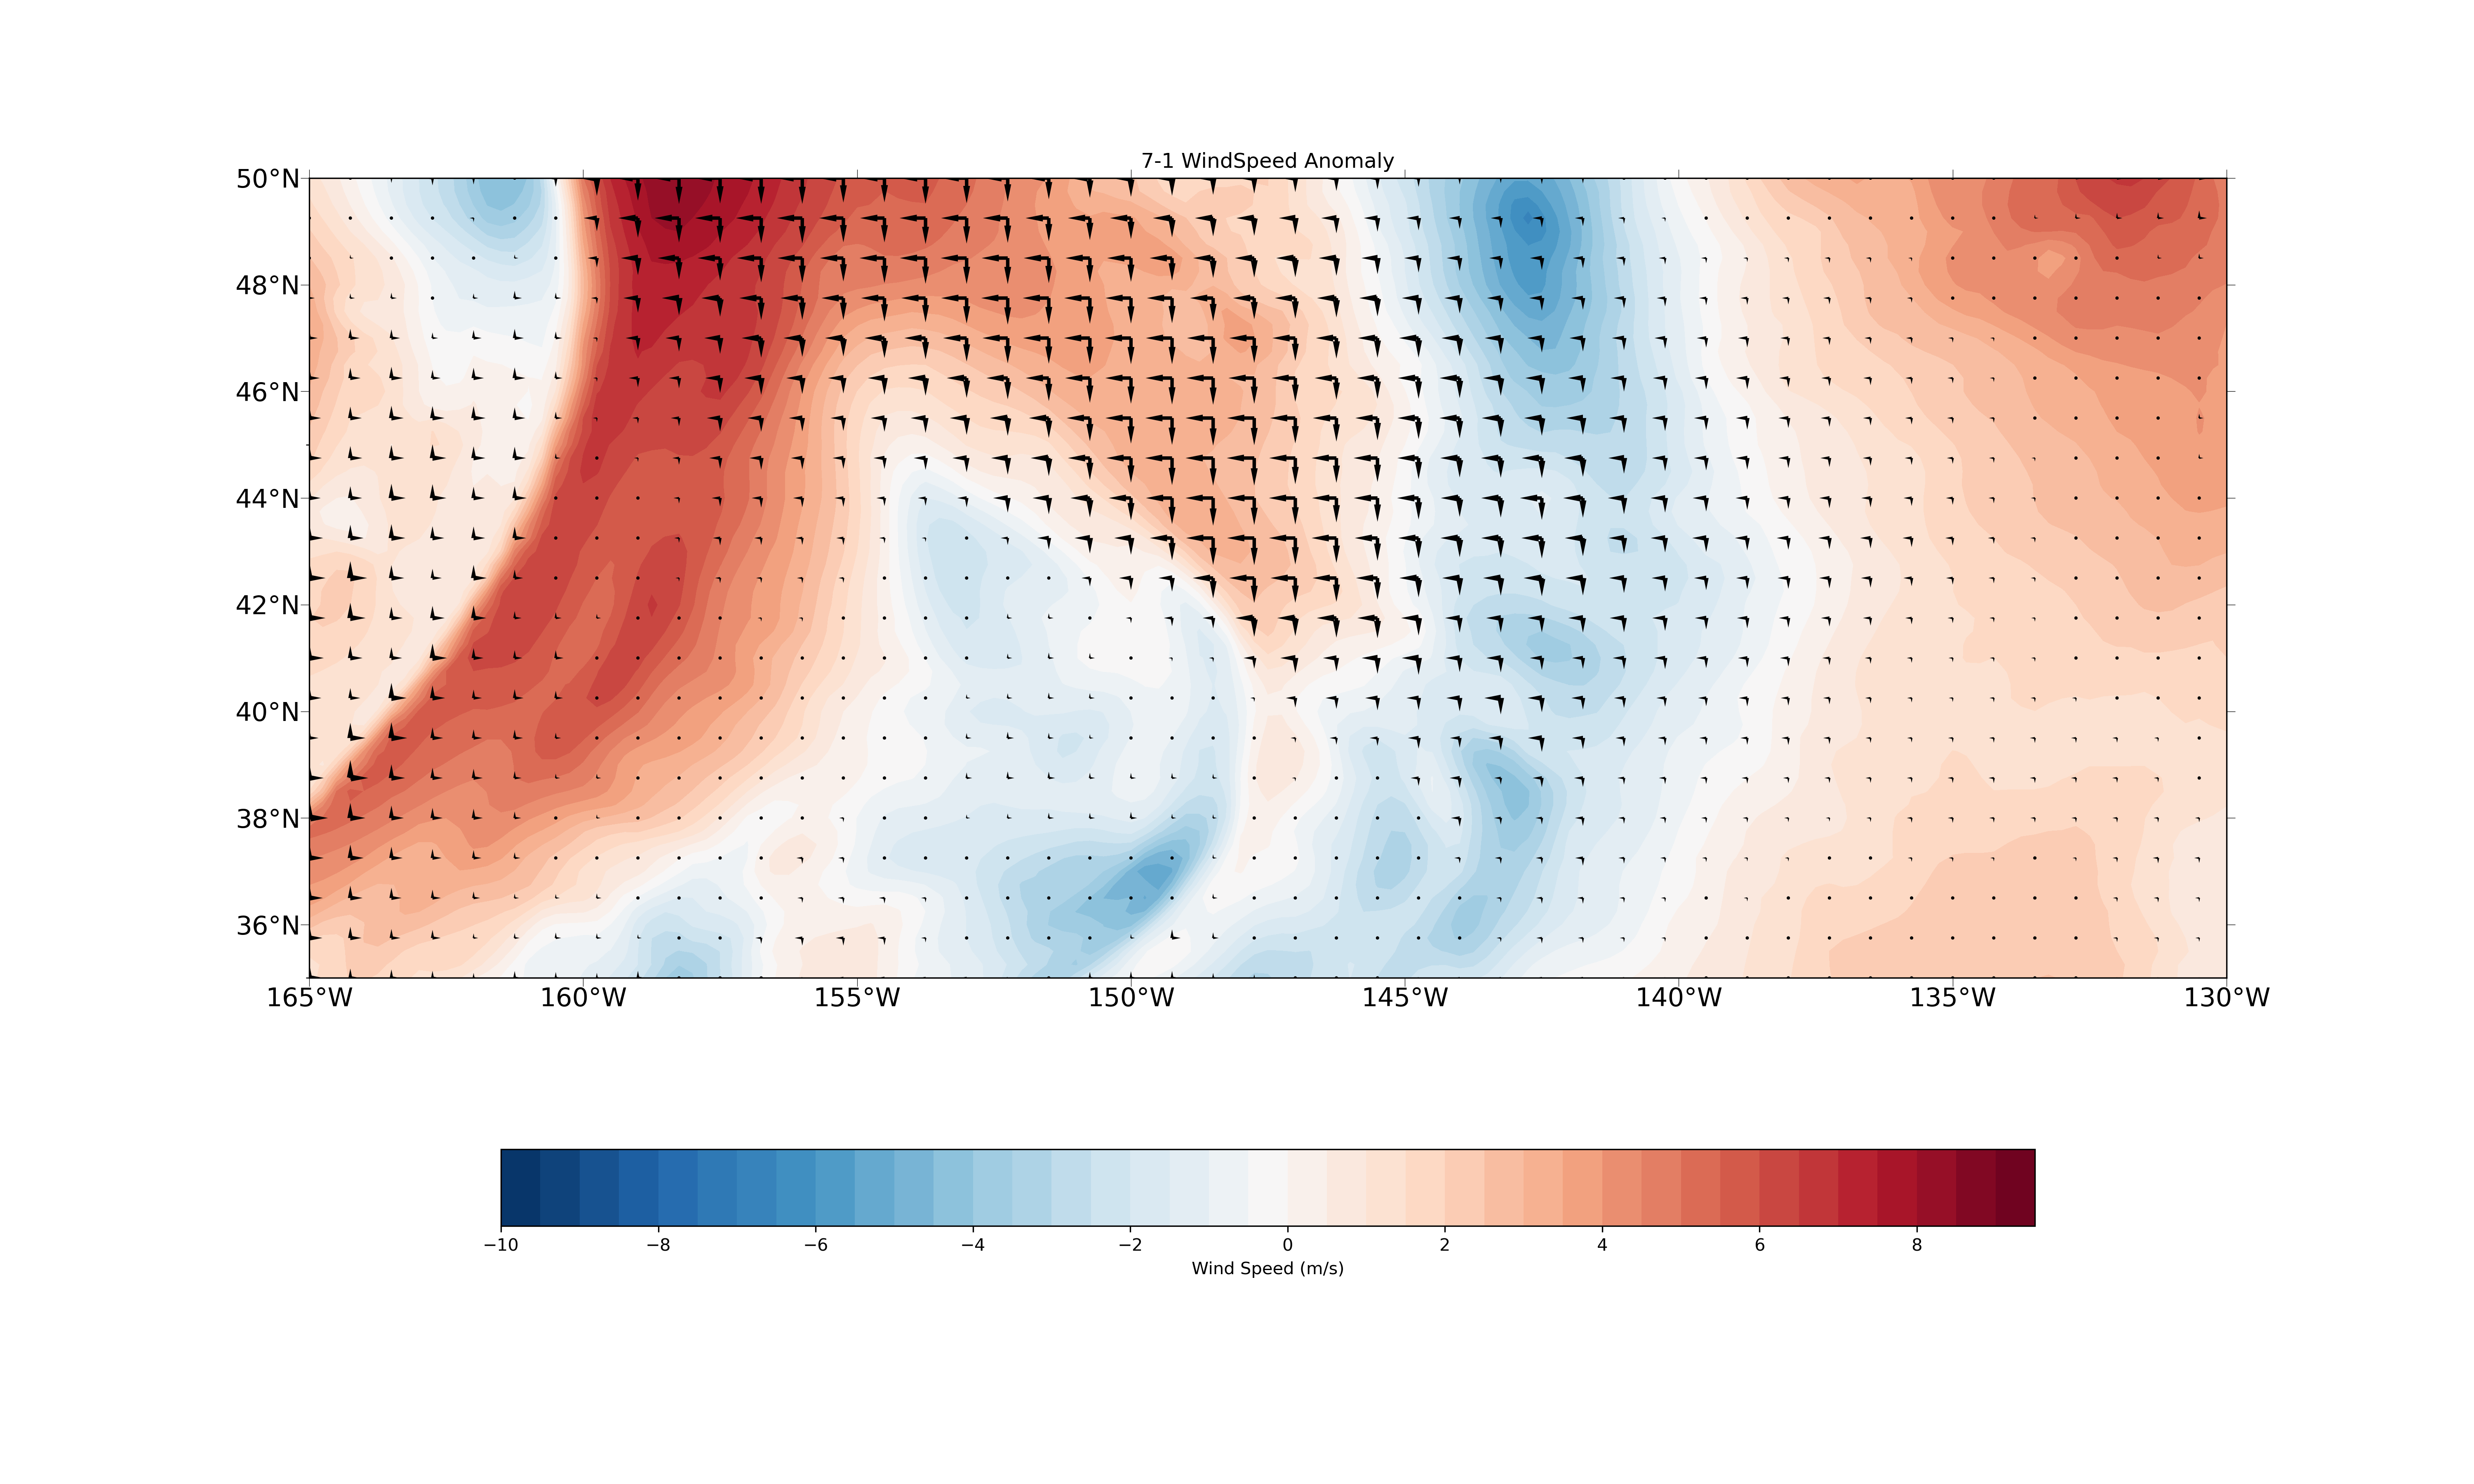

In [209]:
def fig2img(fig):
    """Convert a Matplotlib figure to a PIL Image and return it"""
    buf = io.BytesIO()
    fig.savefig(buf)
    buf.seek(0)
    img = Image.open(buf)
    return img
times=pd.date_range('20210701','20210930',freq='1D')
def draw_wind(n):
    global U10_ano,V10_ano,WindSpeed_ano,Lat,Lon,times
    #import matplotlib 
    #matplotlib.use('Agg')
    ind=(time==times[n])
    demoU=U10_ano[ind,:,:][0,:,:]
    demoV=U10_ano[ind,:,:][0,:,:]
    ig, ax = plt.subplots(figsize=(20,12),dpi=300)
    #print(WindSpeed_ano[ind,:,:].shape)
    c=ax.contourf(Lon,Lat,WindSpeed_ano[ind,:,:][0,:,:],np.arange(-10,10,0.5),cmap='RdBu_r')
    vec=ax.quiver(Lon[::3,::3],Lat[::3,::3],demoU[::3,::3],np.zeros(shape=demoV.shape)[::3,::3],pivot='tail',width=0.0018,headwidth=2,headaxislength=5,scale=700)
    vec=ax.quiver(Lon[::3,::3],Lat[::3,::3],np.zeros(shape=demoU.shape)[::3,::3],demoV[::3,::3],pivot='tail',width=0.0018,headwidth=2,headaxislength=5,scale=700)
    ax.xaxis.set_major_formatter(LongitudeFormatter())#刻度格式转换为经纬度样式 
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))#刻度格式转换为经纬度样式 
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(5))
    ax.tick_params(axis='both',which='major',labelsize=15,direction='out',length=5,width=0.3,pad=0.2,top=True,right=True)
    plt.colorbar(c,orientation='horizontal',label='Wind Speed (m/s)',shrink=0.8)
    plt.title(f'{times[n].month}-{times[n].day} WindSpeed Anomaly')
    #plt.savefig(f'1_20_pic/{n}.png')
    image=fig2img(plt.gcf())
    return image
draw_wind(0)

In [202]:
pool = ProcessPoolExecutor(max_workers=72)
images=list(pool.map(draw_wind,range(times.shape[0])))
del pool
#im = images[0]
#filename = 'test.gif'
#im.save(fp=filename, format='gif', save_all=True, append_images=images[1:], duration=250,loop=0)

In [ ]:
images=[]
for i in range(times.shape[0]):